In [2]:
!pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 3.3 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing import image

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    plt.figure(figsize=(6, 6))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title("Grad-CAM : Zone d'intérêt de l'IA")
    plt.show()

print("Fonctions Grad-CAM prêtes !")

Fonctions Grad-CAM prêtes !


In [4]:
# Choix d'une image de test
img_path = '../data/raw/melanoma/HAM10000_images_part_1/ISIC_0027204.jpg'

# Préparation de l'image au format (224, 224)
img_size = (224, 224)
img_orig = image.load_img(img_path, target_size=img_size)
x = image.img_to_array(img_orig)
x = np.expand_dims(x, axis=0) / 255.0

print("Image chargée et préparée avec succès !")

Image chargée et préparée avec succès !


In [6]:
import tensorflow as tf

# Charger ton modèle déjà entraîné et sauvegardé
model_transfer = tf.keras.models.load_model('../models/medroute_melanoma_model.h5')
print("Modèle chargé avec succès !")

E0000 00:00:1789839968.944586  248447 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Modèle chargé avec succès !


/home/yassine/MedRoute-AI/medroute/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


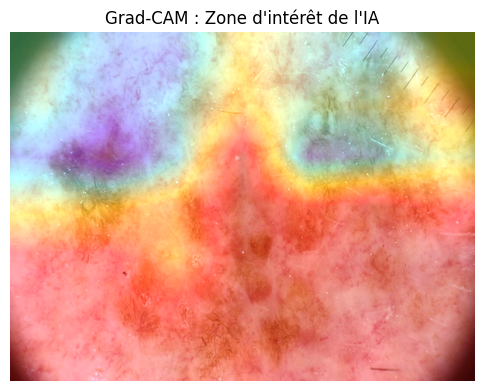

In [7]:
# Nom de la dernière couche de convolution dans MobileNetV2
last_conv_layer_name = "out_relu"

# Génération de la heatmap avec ton modèle entraîné (model_transfer)
heatmap = make_gradcam_heatmap(x, model_transfer, last_conv_layer_name)

# Affichage du résultat
display_gradcam(img_path, heatmap)